## PURPOSE

The purpose of this notebook is to create a dataset of simulated ssep data. Using the custom functions created in the custom_classes.py file, we will create a dataset of simulated ssep data. The dataset will be used to test the preprocessor pipeline and the machine learning models that we will be using in the project. The idea is to generate n number of datasets with specific attributes (eg. full peak amplitude, abolished amplitude, and so on). Then we will generate some JPEG image reports with the mean, odd even mean, and other attributes of the simulated data. These JPEGs are then going to be used to test the classification models of this project


Here we import the custom classes. The classes include the following:
- Peak and Peak children classes: Classes to create custom waveforms
- Processing step and preprocessor classes: Classes to build the preprocessor pipeline for the simulated data.
- waveletfamily class: Class to create custom wavelet families for the wavelet transform step of the  pipeline.
- Dataset: this is what stores all the simulated data and attributes. It also has functions to generate the JPEG reports for the simulated data (still need to modify the function to do this)

In [1]:
# import libraries
import numpy as np
from fontTools.misc.plistlib import end_data

from custom_classes import *
from matplotlib import pyplot as plt
import pandas as pd

dir()
print(GaussianReboundPeak)
print(type(GaussianReboundPeak))


<class 'custom_classes.GaussianReboundPeak'>
<class 'type'>


Here we will create the peak objects that we will use to create the simulated data. We want to create a peak set for each of the following conditions:
- Normal peak set: this will be the baseline peak set that we will use to create the normal simulated data. It will have a full peak amplitude and a normal shape.
- Abolished peak set: this will be the peak set that we will use to create the abolished simulated data. It will have a very low peak amplitude and a distorted shape.
- Reduced peak set: this will be the peak set that we will use to create the reduced simulated data. It will have a reduced peak amplitude and a slightly distorted shape.
- High noise peak set: this will be the peak set that we will use to create the high noise simulated data. It will have a normal peak amplitude but be very noisy.

In [27]:
settings_for_dataset = {
    "fs": 2000,
    "tmin_ms": -50,
    "tmax_ms": 200,
    "pad_frac": 3.0,
    "crop_after_preprocess": False,
    "latency_jitter_ms": 0,
    "amp_jitter_frac": 0.0,
    "noise_rms_uv": 0.5,
    "noise_type": "pink",
    "n_trials" : 300,
    "generate" : True
}



# set parameters here
p45_delay = 45.0
p45_amp_uv = +2
p45_width_ms = 5.0
p45_rebound_frac = 1.5
p45_rebound_delay_ms = 7
p45_rebound_width_ms = 5.0

p75_delay = 75.0
p75_amp_uv = +2
p75_width_ms = 6

# delay for the delayed peaks
peak_delay = 10 # in ms

# multiplied for the reduced peaks
peak_multiplier = 0.5

norm_peaks = [
    GaussianReboundPeak("P45", latency_ms=p45_delay, amp_uv=p45_amp_uv, width_ms=p45_width_ms,
                        rebound_frac=p45_rebound_frac, rebound_delay_ms=p45_rebound_delay_ms, rebound_width_ms=p45_rebound_width_ms),
    Peak("P75", latency_ms=p75_delay, amp_uv=p75_amp_uv, width_ms=p75_width_ms)
]

delayed_peaks = [
    GaussianReboundPeak("P45", latency_ms=p45_delay+peak_delay, amp_uv=p45_amp_uv, width_ms=p45_width_ms,
                        rebound_frac=p45_rebound_frac, rebound_delay_ms=p45_rebound_delay_ms+peak_delay, rebound_width_ms=p45_rebound_width_ms),
    Peak("P75", latency_ms=p75_delay+peak_delay, amp_uv=p75_amp_uv, width_ms=p75_width_ms)
]

reduced_peaks = [
    GaussianReboundPeak("P45", latency_ms=p45_delay, amp_uv=p45_amp_uv*peak_multiplier, width_ms=p45_width_ms,
                        rebound_frac=p45_rebound_frac, rebound_delay_ms=p45_rebound_delay_ms, rebound_width_ms=p45_rebound_width_ms),
    Peak("P75", latency_ms=p75_delay, amp_uv=p75_amp_uv*peak_multiplier, width_ms=p75_width_ms)
]

reduced_delayed_peaks = [
    GaussianReboundPeak("P45", latency_ms=p45_delay+peak_delay, amp_uv=p45_amp_uv*peak_multiplier, width_ms=p45_width_ms,
                        rebound_frac=p45_rebound_frac, rebound_delay_ms=p45_rebound_delay_ms+peak_delay, rebound_width_ms=p45_rebound_width_ms),
    Peak("P75", latency_ms=p75_delay+peak_delay, amp_uv=p75_amp_uv*peak_multiplier, width_ms=p75_width_ms)
]


# normal waveform 30-35 (check)
# conditions - normal latency or delayed or abolished and delayed.

# Dataset simulation
Here we will create the dataset of simulated ssep data. First we will define the parameters for the simulation including number of subjects per condtions, number of trials, the peak sets for each condition. Then we generate a dummy dataset to create the preprocessor pipeline. This same dataset will be used in the next cell to create the corresponding wavelet family for the time frequency decomposition.

In [28]:
# based on settings
condition_peaks = {
    "normal": norm_peaks,
    "delayed": delayed_peaks,
    "reduced": reduced_peaks, # amplitudes are reduced by 50% compared to normal
    "reduced_delayed": reduced_delayed_peaks # uses the normal peaks and will add lots of noise when generating the data
}

#condition_settings = {
#    "normal": settings_for_dataset,
#    "abolished": settings_for_dataset,
#    "reduced": settings_for_dataset,
#    "high_noise": {**settings_for_dataset, "noise_rms_uv": 10.0}, # increase noise for high noise condition
#    "high_temp_jitter": {**settings_for_dataset, "latency_jitter_ms": 5.0} # increase latency jitter for high temp jitter condition
#}



Generated 300 trials with 2000 time points each.
First trial time range: -425.0 ms to 574.5 ms
First trial signal snippet: [-0.02062977  0.12652793  0.00281494  0.41317965  0.11071536  0.06808287
 -0.10214    -0.0810097  -0.26172502 -0.42896842] ...


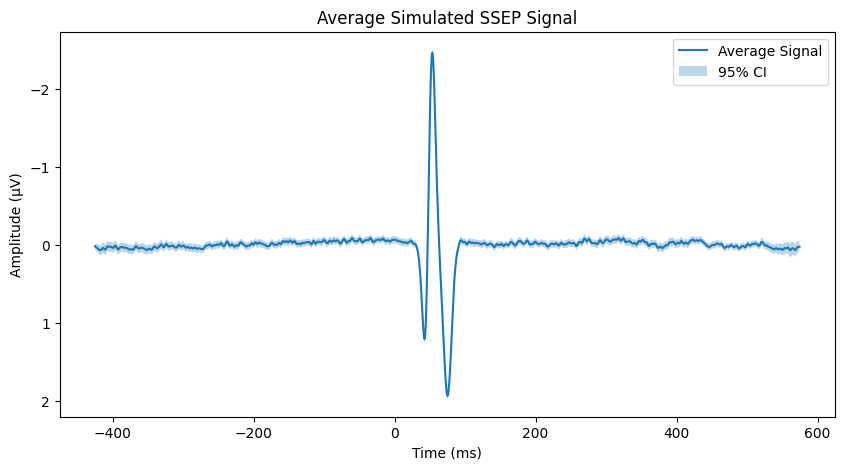

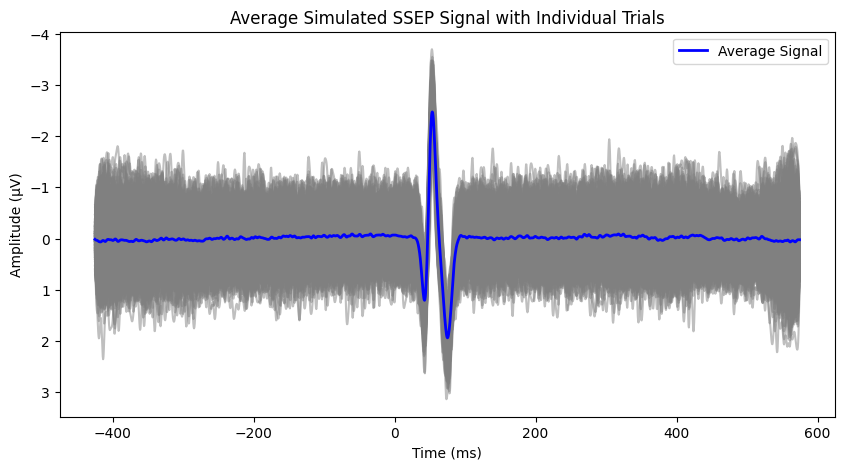

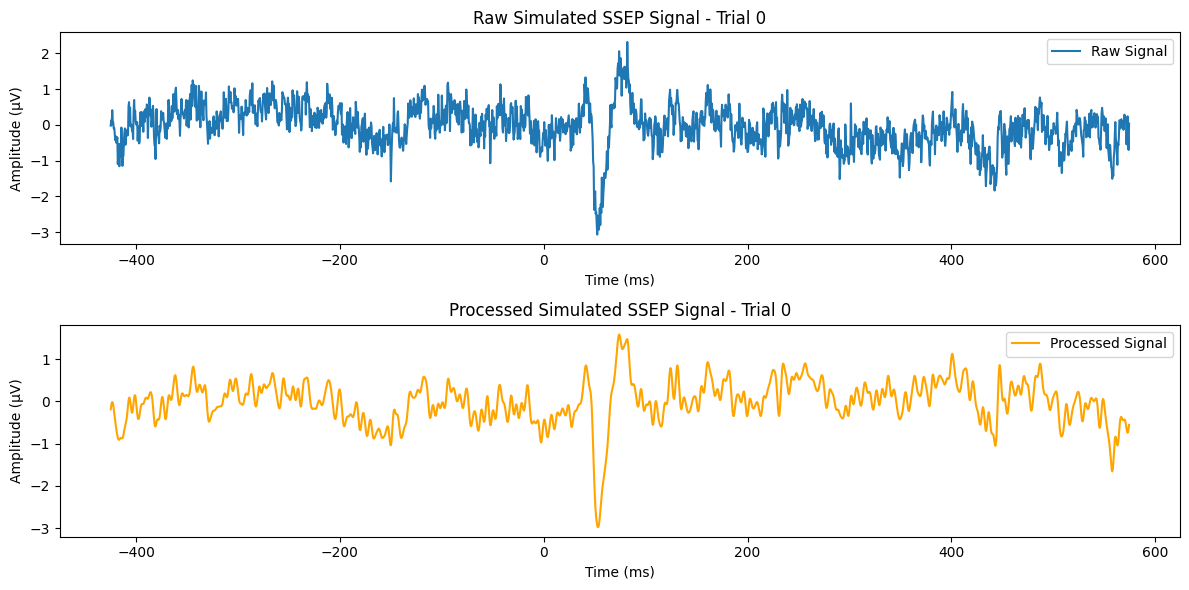

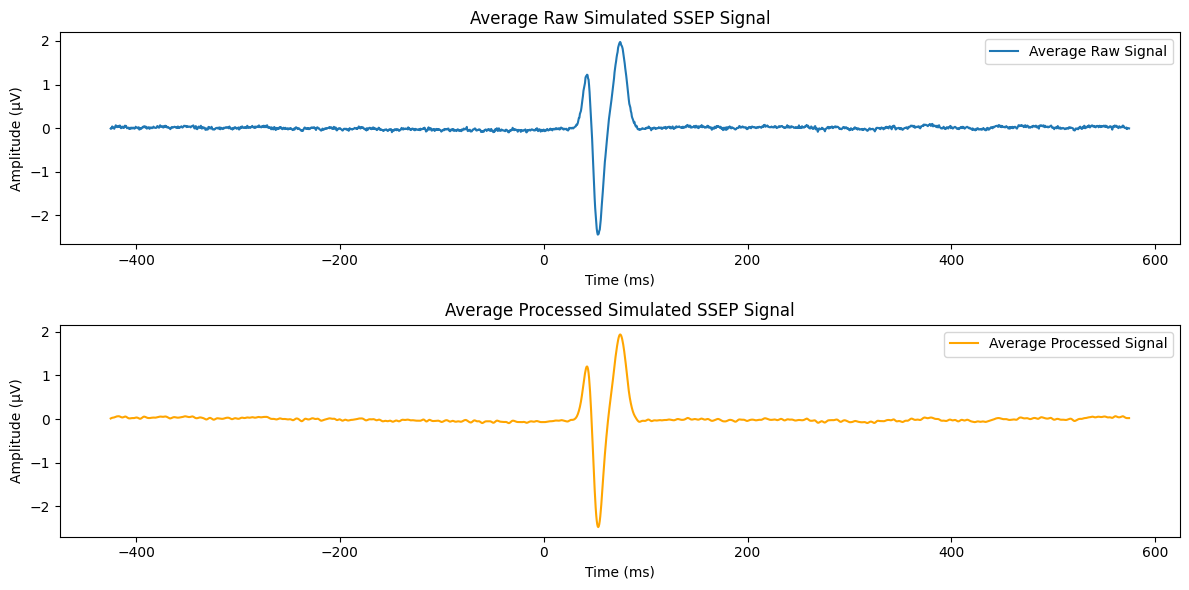

In [29]:
# creating the dummy dataset and actually adding the preprocessor
# dummy dataset to test the dataset class to create the preprocessor pipeline and the wavelet transform settings
dataset = Dataset(peaks=norm_peaks, **settings_for_dataset)

#ataset.generate_trials(n_trials=n_trials)

#print some info about the generated dataset
print(f"Generated {len(dataset.trials)} trials with {len(dataset.trials[0][0])} time points each.")
print(f"First trial time range: {dataset.trials[0][0][0]} ms to {dataset.trials[0][0][-1]} ms")
print(f"First trial signal snippet: {dataset.trials[0][1][:10]} ...")

# apply a simple preprocessing step to the dataset and check that it works without errors
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
dataset.preprocess(preprocessor)

dataset.plot_average(show_ci=True)
dataset.plot_average_with_trials()
dataset.plot_trial_comparison(trial_index=0)
dataset.plot_average_comparison()

Now we will create the wavelet family for the time frequency decomposition step of the preprocessor pipeline. We will use a Morlet wavelet family with a range of frequencies from 5 to 150 Hz. We will define them using the waveletfamily class and define the resolutions witht he fwhm parameter. The fwhm will be defined as a linear function of frequency, with a minimum of 0.01 seconds at the highest frequency and a maximum of 0.03 seconds at the lowest frequency. This means that the wavelets will have a higher temporal resolution at higher frequencies and a lower temporal resolution at lower frequencies, which is a common approach in time-frequency analysis to balance the trade-off between time and frequency resolution. The parameters are a bit arbitrary and can be adjusted.

C:\Users\ortizo\IdeaProjects\ssep_simulation\custom_classes.py:264: UserWarning: Some wavelets contain fewer than 3 cycles.
  f=10.00 Hz → 1.00 cycles
  f=11.84 Hz → 1.17 cycles
  f=13.67 Hz → 1.33 cycles
  f=15.51 Hz → 1.48 cycles
  f=17.35 Hz → 1.64 cycles
  f=19.18 Hz → 1.78 cycles
  f=21.02 Hz → 1.92 cycles
  f=22.86 Hz → 2.06 cycles
  f=24.69 Hz → 2.19 cycles
  f=26.53 Hz → 2.31 cycles
  f=28.37 Hz → 2.43 cycles
  f=30.20 Hz → 2.55 cycles
  f=32.04 Hz → 2.65 cycles
  f=33.88 Hz → 2.76 cycles
  f=35.71 Hz → 2.86 cycles
  f=37.55 Hz → 2.95 cycles
  warnings.warn(


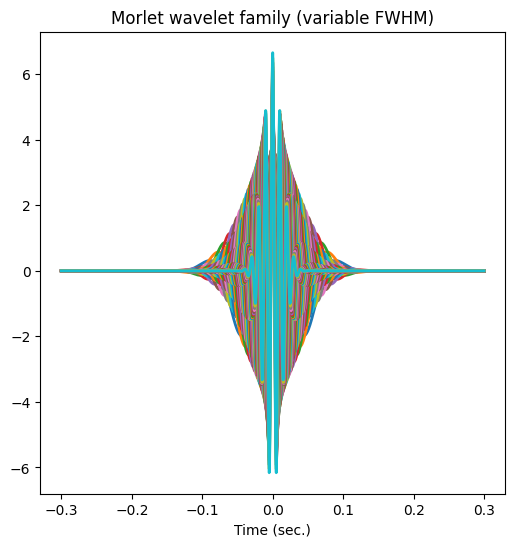

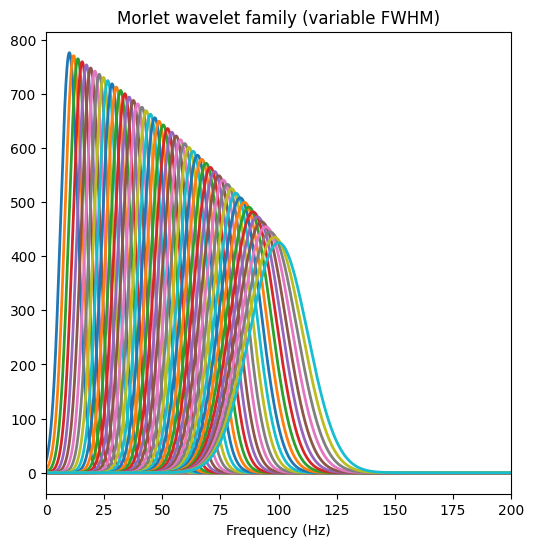

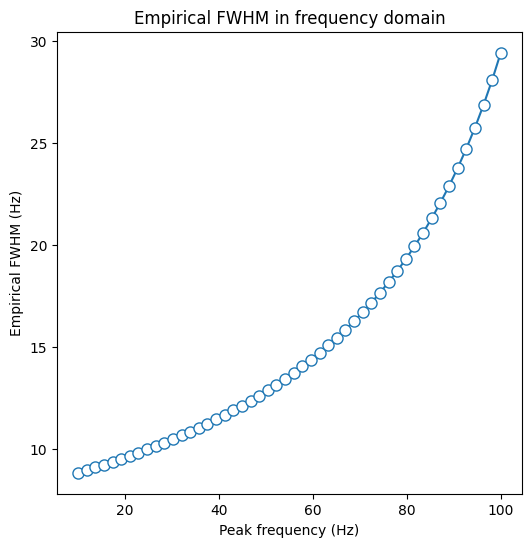

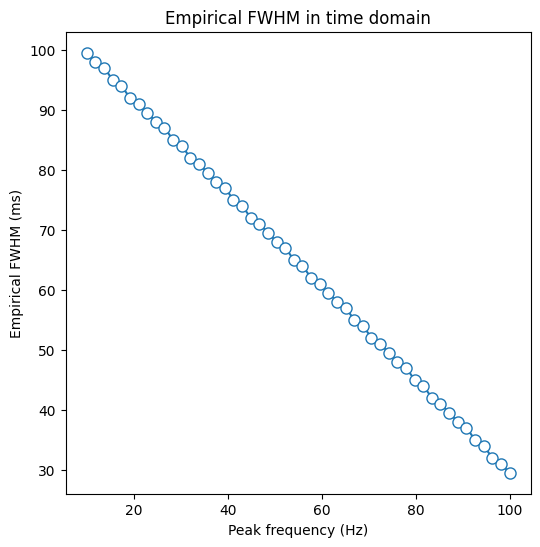

array([[0.0150341 , 0.01571487, 0.01644432, ..., 0.0085349 , 0.00907756,
        0.00966731],
       [0.0229955 , 0.02330135, 0.02358471, ..., 0.0170106 , 0.01734168,
        0.01766395],
       [0.02260728, 0.02254865, 0.02298515, ..., 0.02441581, 0.02389001,
        0.02322286],
       ...,
       [0.05458885, 0.05463221, 0.05619518, ..., 0.06074367, 0.06048691,
        0.06028305],
       [0.05959126, 0.06165572, 0.06352923, ..., 0.0574046 , 0.06206453,
        0.06377011],
       [0.05316396, 0.05493762, 0.05638584, ..., 0.05246253, 0.05474945,
        0.05716499]], shape=(50, 2000), dtype=float32)

In [40]:
srate = dataset.fs
n_frex = 50
frex = np.linspace(10, 100, n_frex)
fwhm = np.linspace(0.04, 0.01, n_frex)  # seconds
fwhm = np.linspace(.1, 0.03, n_frex)  # seconds
wav_half_length_s = .3  # half-length in seconds (so total duration = .5 * this)
wavtime = np.arange(
    -wav_half_length_s,
    wav_half_length_s + 1/srate,
    1/srate
)# set nData to the length of the simulated signals in dataset (after padding)
# get actual sizes from dataset
EEGpnts = len(dataset.trials[0][1])     # time points per trial
EEGtrials = len(dataset.trials)         # number of trials
# Cohen-style concatenated nData:
nData = EEGpnts * EEGtrials

wavefam = wavelet_family(frex=frex, fwhm=fwhm, srate=srate, wavtime=wavtime, n_data=nData,amp_norm = "energy").build()

# display family of wavelets to see the time and frequency resolution
wavefam.plot_time_family(real_part=True)
wavefam.plot_freq_family(fft_peak_normalize = False)
wavefam.plot_empirical_fwhm_freq()
wavefam.plot_empirical_fwhm_time(ms=True)


# try on test dataset
# 1) compute complex TF once
dataset.compute_tf_complex_from_wavelet_family(wavefam, store=True,)

# 2) compute metrics anytime
m = dataset.tf_metrics(baseline_ms=(-20, 0), kind="db", store=True)

m["total_power_norm"]    # (freq, time)
m["induced_power_norm"]
m["evoked_power_norm"]
m["itpc"]



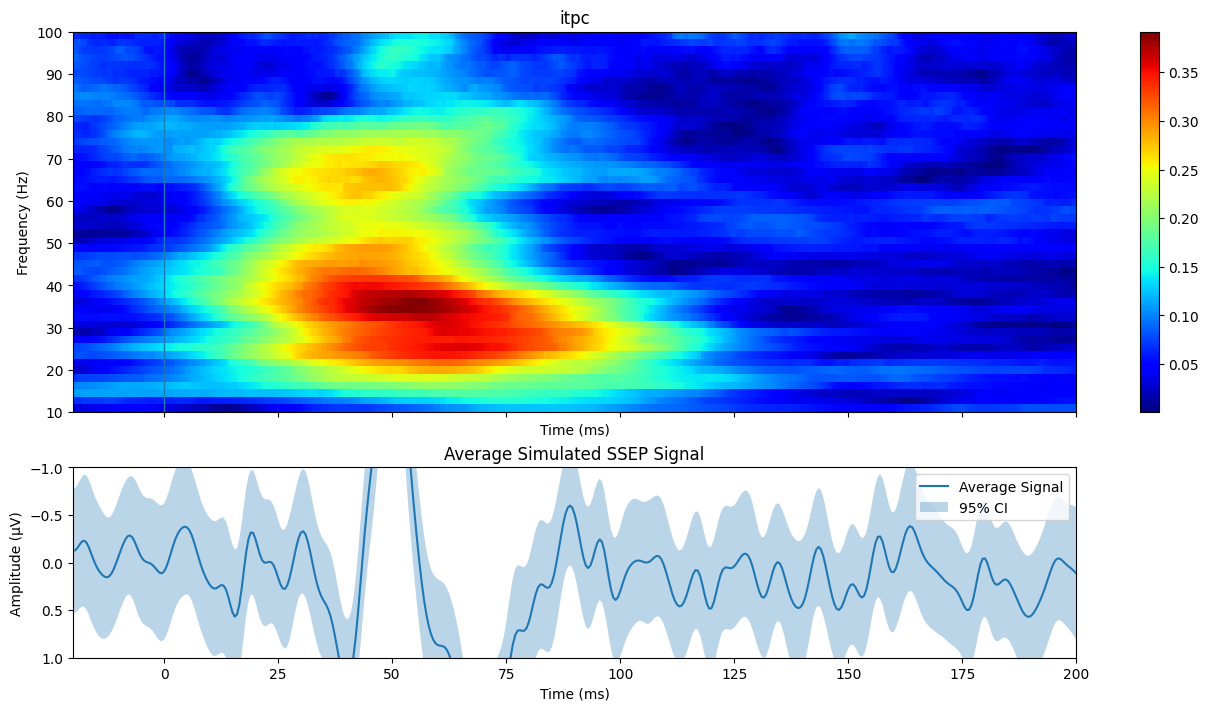

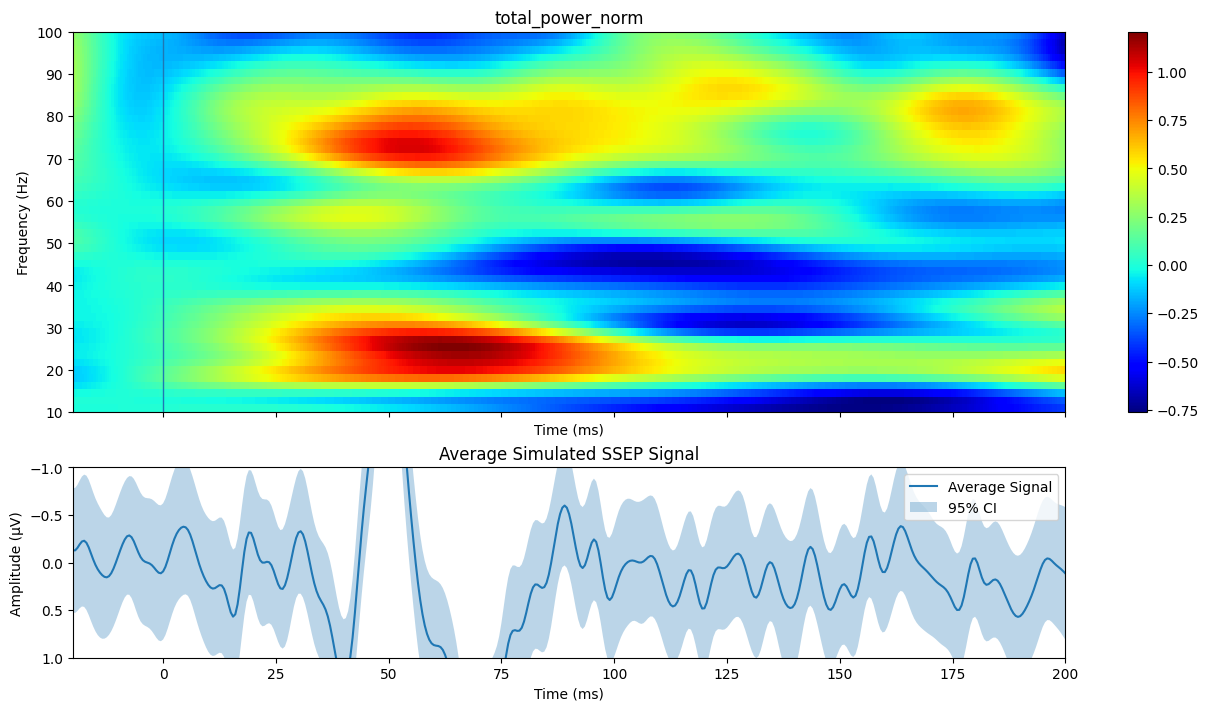

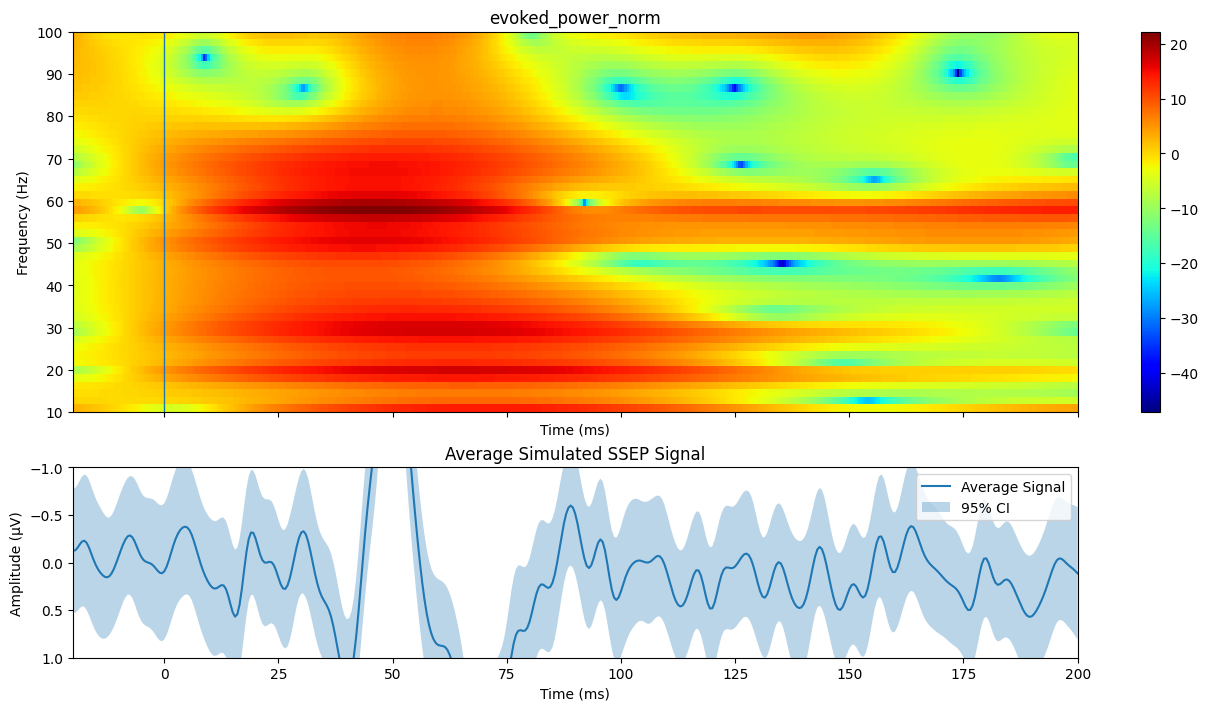

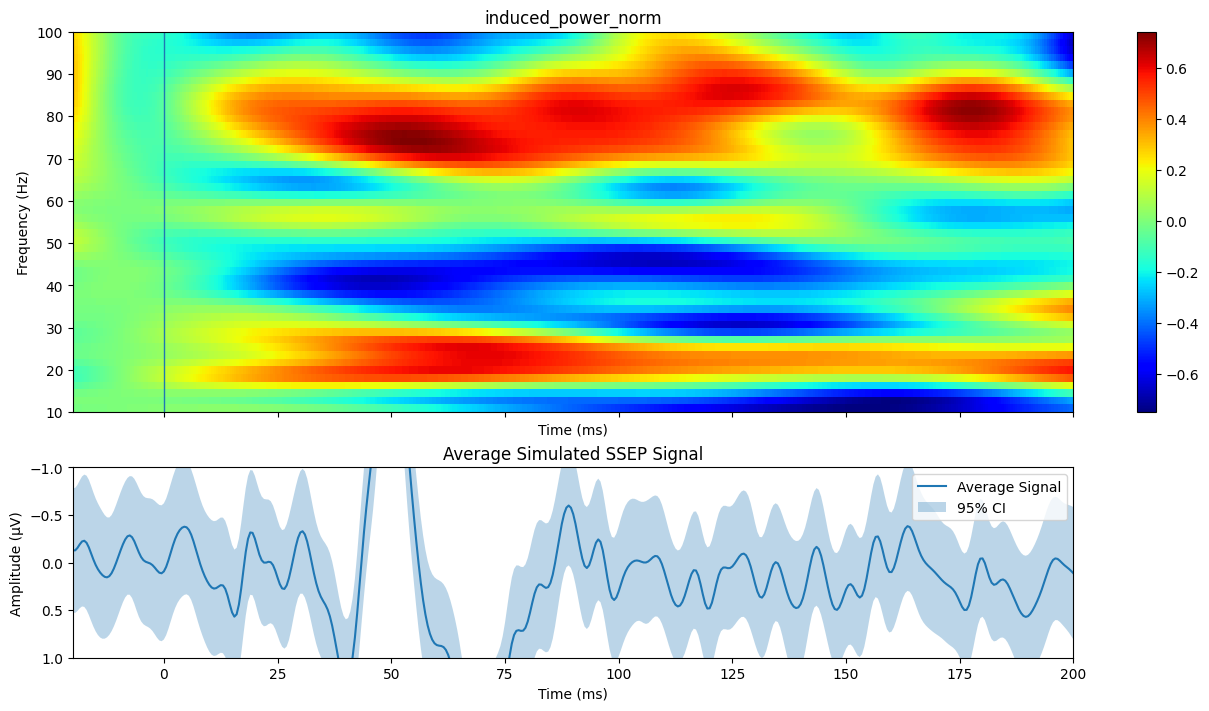

In [41]:
# here we do the tf decomposition for a zero amp and time jitter

# try the report generation
fig = dataset.plot_report(
    tf_metric="itpc",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(0, .7),
    show=False
)
# try the report generation
fig = dataset.plot_report(
    tf_metric="total_power_norm",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(0, .7),
    show=False
)

fig = dataset.plot_report(
    tf_metric="evoked_power_norm",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(0, .7),
    show=False
)

fig = dataset.plot_report(
    tf_metric="induced_power_norm",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(0, .7),
    show=False
)


Here we will generate the simulated datasets for each condition. We will loop through the condition_peaks and select the corresponding peaks and settings for each condition. Then we will create a dataset for each subject, preprocess it, compute the transform and extract the metrics. We will also generate the JPEG reports for each dataset (still need to modify the function to do this). We should also store the settings used to generate that specific subject dataset in a metadatasheet for later reference when we test the machine learning models. The metadata should include the condition name, the peaks used, the settings used, and any other relevant information about the dataset.

In [42]:
# loop over conditions. Probably do not want to store all datasets in memory at the same time, so we can generate one dataset at a time, preprocess it, compute the transform and metrics, generate the report, and then move on to the next dataset. We can store the metadata for each dataset in a list of dictionaries, and then convert that list to a DataFrame at the end for easier analysis and reference. We also store the average waveform per subject and condition in a dictionary for later reference when we test the machine learning models. The keys of the dictionary will be a tuple of (condition_name, subject_number) and the values will be the average waveform for that subject and condition.  Wi will do the same with the ITPC maps, storing them in a dictionary with keys as tuples of (condition_name, subject_number) and values as the ITPC maps for that subject and condition. This way we can easily access the average waveforms and ITPC maps for each subject and condition when we test the machine learning models.


# paramters
n_subs_per_condition = 50
# subject specific settings - these will introduce intersubject variability across the different condition. this is done through modifiers in the loop that add latency or multiply the amplitude of each subject response according to a random varable selector in the loop around these ranges
subject_specific_amp_range_uv = {"low": .7, "high": 1.3}   # will modify the amplitude by multiplying it by a modifier
subject_specific_latency_range_ms = {"low": -10, "high": 11}  # will modify the subject latency by adding this modifier- should be plus or minus 10


# here we define the settings for the actual simulation
settings_for_dataset = {
    "fs": 2000,
    "tmin_ms": -50,
    "tmax_ms": 200,
    "pad_frac": 3.0,
    "crop_after_preprocess": False,
    "latency_jitter_ms": 1,
    "amp_jitter_frac": 0.5,
    "noise_rms_uv": 7,
    "noise_type": "pink",
    "n_trials" : 300,
    "generate" : True
}

# reset the dataset settings per condition
condition_settings = {
    "normal": settings_for_dataset,
    "delayed": settings_for_dataset,
    "reduced": settings_for_dataset, # amplitudes are reduced by 50% compared to normal
    "reduced_delayed": settings_for_dataset, # uses the normal peaks and will add lots of noise when generating the data
}





metadata_list = []
average_waveforms = {}
itpc_maps = {}
time_axes = {}
tf_time_axes = {}
tf_freq_axes = {}
for condition_name, peaks in condition_peaks.items():
    print(f"Generating datasets for condition: {condition_name}")
    settings = condition_settings[condition_name]

    for sub in range(n_subs_per_condition):
        print(f"  Generating dataset for subject {sub+1}/{n_subs_per_condition}")

        # introduce subject specific amplitude and latency by modifying the peaks for this subject based on the base peaks for this condition
        subject_peaks = []
        subject_specific_amp_modifier = np.random.uniform(subject_specific_amp_range_uv["low"],subject_specific_amp_range_uv["high"]) # will modify the amplitude by multiplying it by a modifier
        subject_specific_latency_modifier = np.random.randint(subject_specific_latency_range_ms["low"],subject_specific_latency_range_ms["high"])  # will modify the subject latency by adding this modifier- shouldbe plus or minus 10 ish to match empirical data variability based on height
        for peak in peaks:
            sub_specific_amp = peak.amp_uv * subject_specific_amp_modifier  # subject specific amplitude
            sub_specific_latency = peak.latency_ms +subject_specific_latency_modifier  # subject specific variability

            # check that the latency is not earlier than 35 ms so that we dont get really early responses, and if ti is set it to a random latency slight after 35
            if sub_specific_latency < 35:
                sub_specific_latency = 35 + np.random.randint(0, 2)

            # we have two types of peaks, the GaussianReboundPeak and the regular Peak. We need to check the type of the peak and create the corresponding subject peak with the jittered parameters. For the GaussianReboundPeak, we also need to jitter the rebound parameters if they exist.
            if isinstance(peak, GaussianReboundPeak):
                peak_specific_latency = sub_specific_latency + np.random.randint(-3, 3) # add variability within the peaks
                peak_specific_amp = sub_specific_amp * np.random.uniform(0.95, 1.05)
                subject_peak = GaussianReboundPeak(
                    name=peak.name,
                    latency_ms = peak_specific_latency,
                    amp_uv=peak_specific_amp,
                    width_ms=peak.width_ms + np.random.randint(-2, 2),
                    rebound_frac=peak.rebound_frac,
                    rebound_delay_ms=peak.rebound_delay_ms,
                    rebound_width_ms=peak.rebound_width_ms+np.random.randint(-2, 2) # add some morphological variability
                )
            else:
                peak_specific_latency = sub_specific_latency + np.random.randint(-3, 3) # add variability within the peaks
                peak_specific_amp = sub_specific_amp * np.random.uniform(0.95, 1.05)
                subject_peak = Peak(
                    name=peak.name,
                    latency_ms=peak_specific_latency,
                    amp_uv=peak_specific_amp,
                    width_ms=peak.width_ms + np.random.randint(-2, 2)
                )
            subject_peaks.append(subject_peak)
            print(f"    For peak {peak.name} we have a latency of {peak_specific_latency} and amplitude of  {peak_specific_amp} ")

        # Create dataset
        dataset = Dataset(peaks=subject_peaks, **settings)

        # Preprocess dataset
        preprocessor = Preprocessor(fs=dataset.fs)
        preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
        dataset.preprocess(preprocessor)

        # Compute TF and metrics
        dataset.compute_tf_complex_from_wavelet_family(wavefam, store=True)
        metrics = dataset.tf_metrics(baseline_ms=(-20, 0), kind="db", store=True)
        t_ms, avg = dataset.average()

        time_axes.setdefault(condition_name, t_ms)
        average_waveforms[(condition_name, sub + 1)] = avg
        itpc_maps[(condition_name, sub + 1)] = metrics["itpc"]
        tf_time_axes.setdefault(condition_name, metrics["t_ms"])
        tf_freq_axes.setdefault(condition_name, metrics["frex"])


        # Generate report (this function still needs to be modified to create the JPEG reports with the desired attributes)
        fig = dataset.plot_report(
            figsize=(11, 12),
            tf_metric="itpc",
            tlim_ms=(-20, 150),
            flim_hz=(5, 80),
            erp_ylim=(-4, 4),
            tf_clim=(0, .6),
            show=False
        )
        # save the figure as a JPEG report in simulated_data_subfolder
        fig.savefig(f"simulated_data/simulated_dataset_{condition_name}_sub{sub+1}.jpg", dpi=300)

        #close the figure to free up memory
        plt.close(fig)

        # Store metadata
        # iterate subject peaks and generate metadata using the to_dict method
        for speak in subject_peaks:

            metadata_list.append({
                "condition": condition_name,
                "subject": sub + 1,
                "type_peak": type(speak),
                "peak_amp": speak.amp_uv,
                "peak_latency": speak.latency_ms,
                "width_ms": speak.width_ms,
                "peak_info" : speak.to_dict(),
                "settings": settings
            })



Generating datasets for condition: normal
  Generating dataset for subject 1/50
    For peak P45 we have a latency of 42.0 and amplitude of  1.5324336530639464 
    For peak P75 we have a latency of 73.0 and amplitude of  1.5763115061849173 
  Generating dataset for subject 2/50
    For peak P45 we have a latency of 34.0 and amplitude of  1.712333000650181 
    For peak P75 we have a latency of 66.0 and amplitude of  1.6000446629676117 
  Generating dataset for subject 3/50
    For peak P45 we have a latency of 52.0 and amplitude of  1.5661370325610398 
    For peak P75 we have a latency of 80.0 and amplitude of  1.4869174800276417 
  Generating dataset for subject 4/50
    For peak P45 we have a latency of 44.0 and amplitude of  1.9413193990119642 
    For peak P75 we have a latency of 78.0 and amplitude of  1.9336296489885714 
  Generating dataset for subject 5/50
    For peak P45 we have a latency of 45.0 and amplitude of  2.4010551526662076 
    For peak P75 we have a latency of 79

In [43]:
# save metadata to an ex file for later reference

metadata_df = pd.DataFrame(metadata_list)
metadata_df.to_excel("simulated_data/simulated_datasets_metadata.xlsx", index=False)


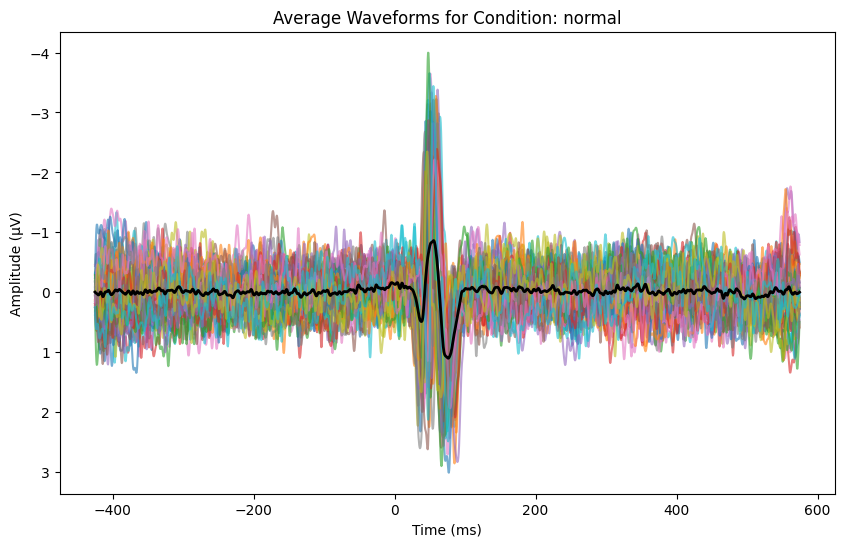

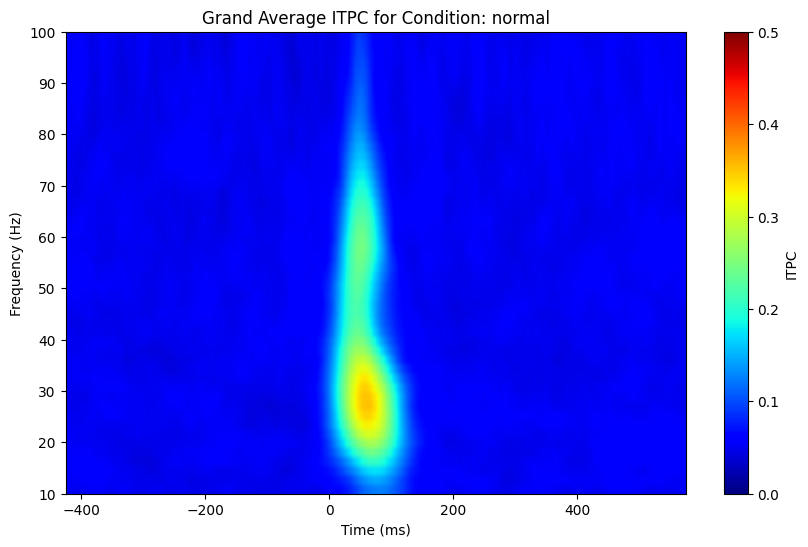

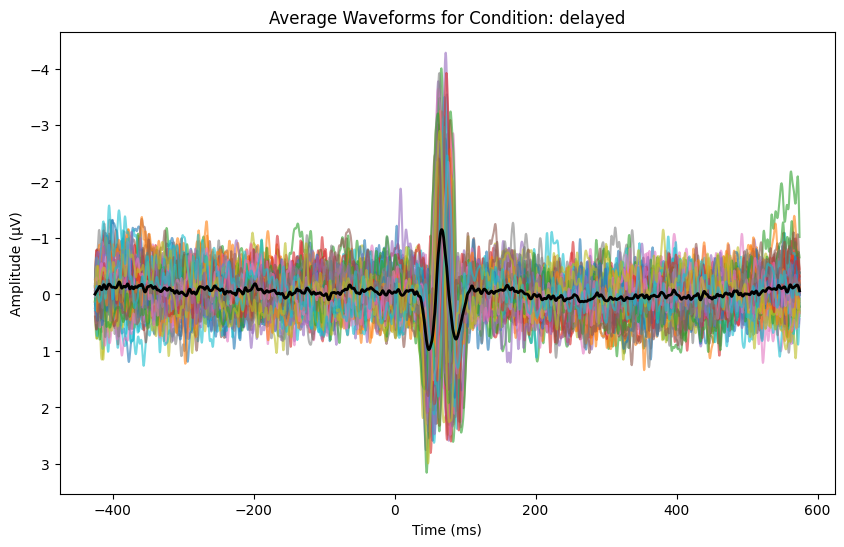

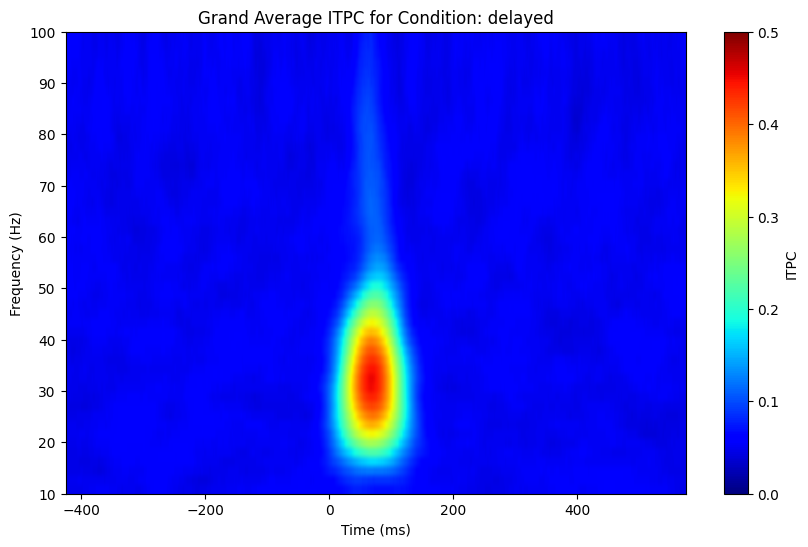

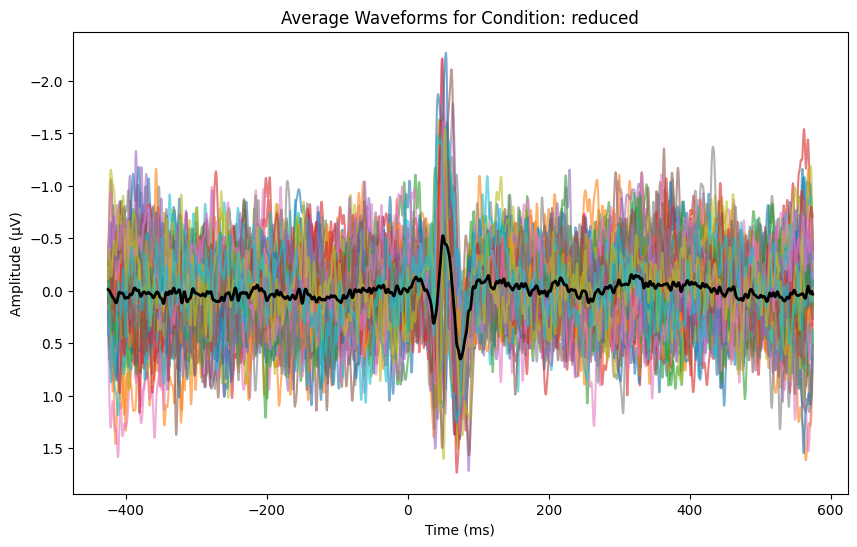

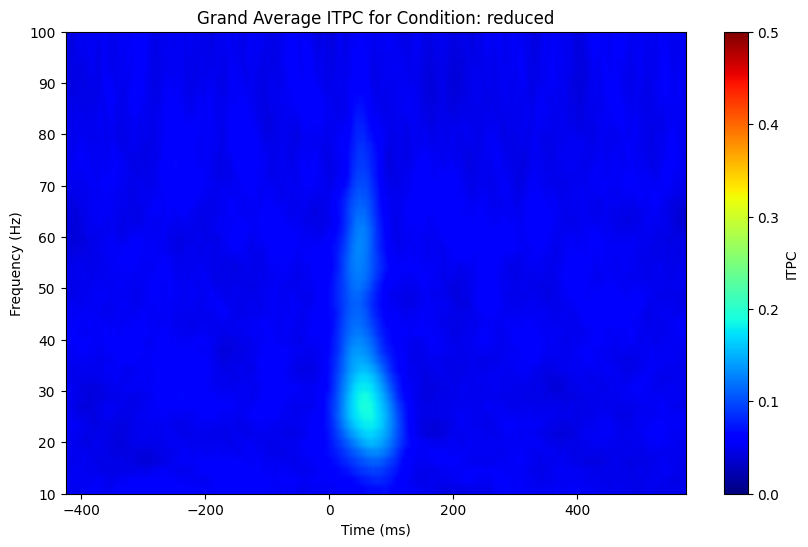

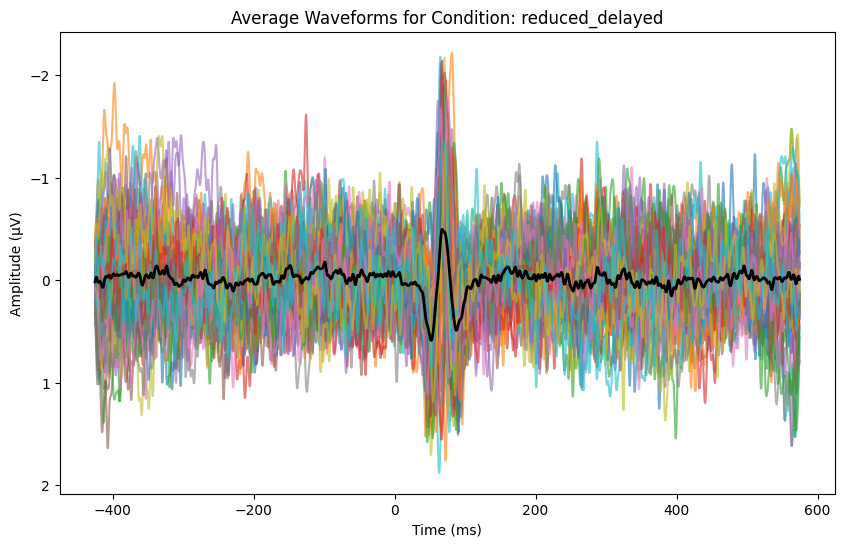

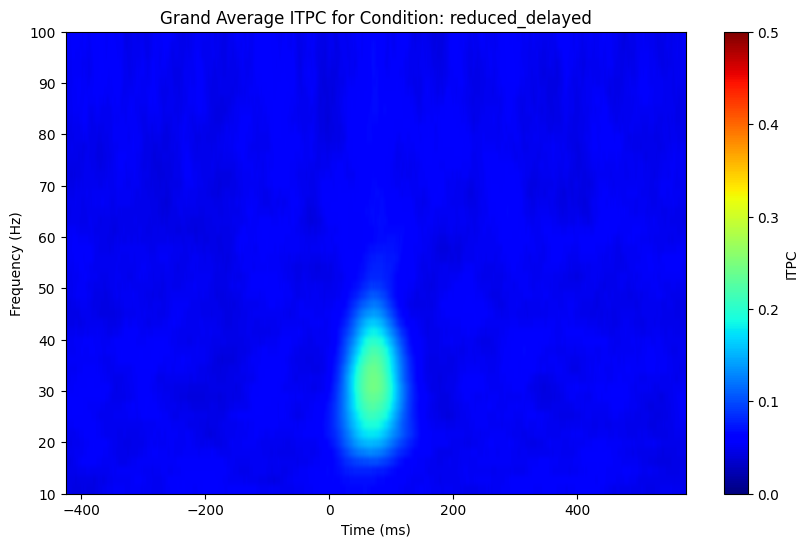

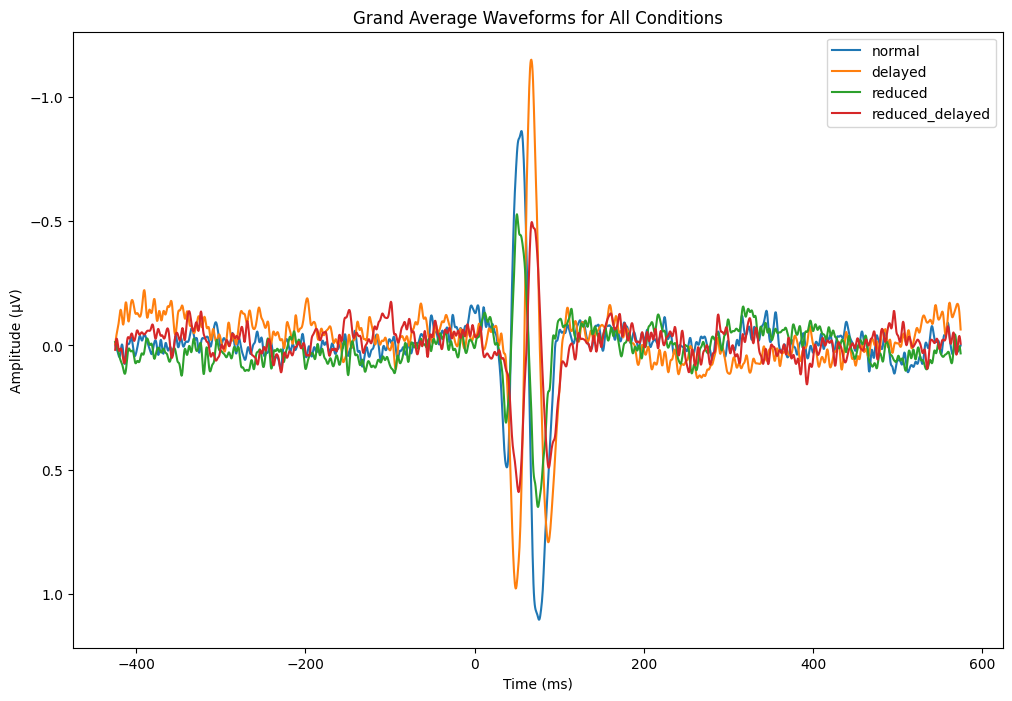

In [44]:
# now we will plot group level average

# plot the average waveforms for each condition and subject to visually inspect the differences between conditions
for condition_name in condition_peaks.keys():
    plt.figure(figsize=(10, 6))

    t_ms = time_axes[condition_name]  # correct time axis for this condition

    subj_avgs = []
    for sub in range(n_subs_per_condition):
        avg = average_waveforms[(condition_name, sub + 1)]
        subj_avgs.append(avg)
        plt.plot(t_ms, avg, alpha=0.6, label=f"Subject {sub + 1}")

    grand_avg = np.mean(np.stack(subj_avgs, axis=0), axis=0)
    plt.plot(t_ms, grand_avg, color="black", linewidth=2, label="Grand Average")

    plt.title(f"Average Waveforms for Condition: {condition_name}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.gca().invert_yaxis()
    #plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))

    itpcs = [itpc_maps[(condition_name, sub + 1)] for sub in range(n_subs_per_condition)]
    grand_itpc = np.mean(np.stack(itpcs, axis=0), axis=0)

    t_tf = tf_time_axes[condition_name]
    frex_tf = tf_freq_axes[condition_name]

    plt.imshow(
        grand_itpc,
        aspect="auto",
        origin="lower",
        extent=[t_tf[0], t_tf[-1], frex_tf[0], frex_tf[-1]],
        cmap="jet",
        vmin=0,
        vmax=0.5,
    )
    plt.colorbar(label="ITPC")
    plt.title(f"Grand Average ITPC for Condition: {condition_name}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (Hz)")
    plt.show()
    # save figures




# plot the averages together for comparison
plt.figure(figsize=(12, 8))
for condition_name in condition_peaks.keys():
    t_ms = time_axes[condition_name]  # correct time axis for this condition
    grand_avg = np.mean(np.stack([average_waveforms[(condition_name, sub + 1)] for sub in range(n_subs_per_condition)], axis=0), axis=0)
    plt.plot(t_ms, grand_avg, label=condition_name)
plt.title("Grand Average Waveforms for All Conditions")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.gca().invert_yaxis()
plt.legend()
